<a href="https://colab.research.google.com/github/Safayat777/my_new/blob/main/Efficientnet%2BTransfer_L.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetV2B3
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

from tensorflow.keras.layers import *
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


In [3]:
train_path = "/content/drive/MyDrive/DataSet/Train"
test_path  = "/content/drive/MyDrive/DataSet/Test"

In [4]:
IMG_SIZE = 300
BATCH_SIZE = 32
EPOCHS = 5

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.20,
    shear_range=0.10,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 6659 images belonging to 2 classes.
Found 2233 images belonging to 2 classes.


In [6]:
base_model = EfficientNetV2B3(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = Input(shape=(IMG_SIZE, IMG_SIZE, 3))

x = base_model(inputs, training=False)

x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)

x = Dense(
    512,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

x = Dropout(0.4)(x)

x = Dense(
    128,
    activation='relu',
    kernel_regularizer=tf.keras.regularizers.l2(1e-4)
)(x)

x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

model.summary()

52606240/52606240 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b3 (Functional)  │ (None, 10, 10, 1536)   │    12,930,622 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,789,503 (52.60 MB)

 Trainable params: 855,809 (3.26 MB)

 Non-trainable params: 12,933,694 (49.34 MB)

In [7]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_EfficientNetV2B3.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

callbacks = [
    early_stop,
    reduce_lr,
    checkpoint
]

In [9]:
history = model.fit(
    train_generator,
    epochs=5,
    validation_data=test_generator,
    callbacks=callbacks
)

Epoch 1/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.7575 - loss: 0.6049
Epoch 1: val_accuracy improved from None to 0.84639, saving model to best_EfficientNetV2B3.keras

Epoch 1: finished saving model to best_EfficientNetV2B3.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 2928s 14s/step - accuracy: 0.8296 - loss: 0.4777 - val_accuracy: 0.8464 - val_loss: 0.4280 - learning_rate: 1.0000e-04
Epoch 2/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 9s/step - accuracy: 0.9063 - loss: 0.3416
Epoch 2: val_accuracy improved from 0.84639 to 0.86968, saving model to best_EfficientNetV2B3.keras

Epoch 2: finished saving model to best_EfficientNetV2B3.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 2423s 12s/step - accuracy: 0.9103 - loss: 0.3226 - val_accuracy: 0.8697 - val_loss: 0.3725 - learning_rate: 1.0000e-04
Epoch 3/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.9257 - loss: 0.2810
Epoch 3: val_accuracy improved from 0.86968 to 0.88939, saving model to best_EfficientNetV2B3.keras

Epoch 3: finished saving mod

In [10]:
base_model.trainable = True

for layer in base_model.layers[:-50]:
    layer.trainable = False

In [11]:
model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
history_fine = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=test_generator,
    callbacks=callbacks
)

Epoch 1/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.9193 - loss: 0.2924 
Epoch 1: val_accuracy did not improve from 0.91491
209/209 ━━━━━━━━━━━━━━━━━━━━ 2724s 13s/step - accuracy: 0.9228 - loss: 0.2837 - val_accuracy: 0.9001 - val_loss: 0.3289 - learning_rate: 1.0000e-05
Epoch 2/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9379 - loss: 0.2551 
Epoch 2: val_accuracy did not improve from 0.91491
209/209 ━━━━━━━━━━━━━━━━━━━━ 2781s 13s/step - accuracy: 0.9380 - loss: 0.2577 - val_accuracy: 0.9127 - val_loss: 0.2942 - learning_rate: 1.0000e-05
Epoch 3/5
209/209 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.9442 - loss: 0.2380 
Epoch 3: val_accuracy improved from 0.91491 to 0.92476, saving model to best_EfficientNetV2B3.keras

Epoch 3: finished saving model to best_EfficientNetV2B3.keras
209/209 ━━━━━━━━━━━━━━━━━━━━ 2853s 14s/step - accuracy: 0.9440 - loss: 0.2422 - val_accuracy: 0.9248 - val_loss: 0.2811 - learning_rate: 1.0000e-05
Epoch 4/5
209/209 ━━━━━━━━━━━━━━━

In [13]:
loss, accuracy = model.evaluate(test_generator)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

70/70 ━━━━━━━━━━━━━━━━━━━━ 578s 8s/step - accuracy: 0.9306 - loss: 0.2629
Test Loss: 0.2629336416721344
Test Accuracy: 0.9305866360664368


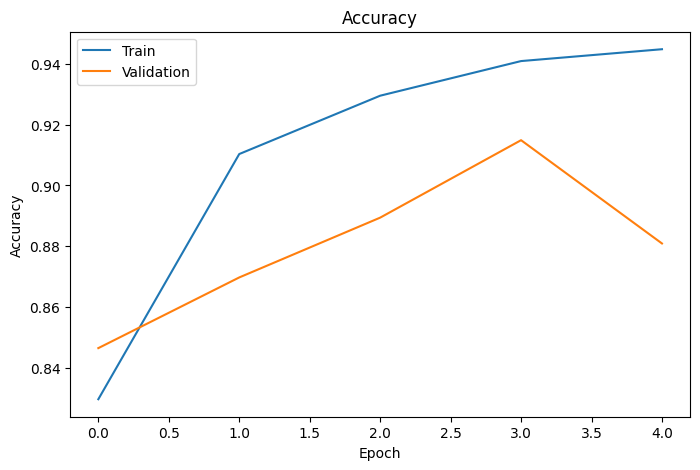

In [14]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

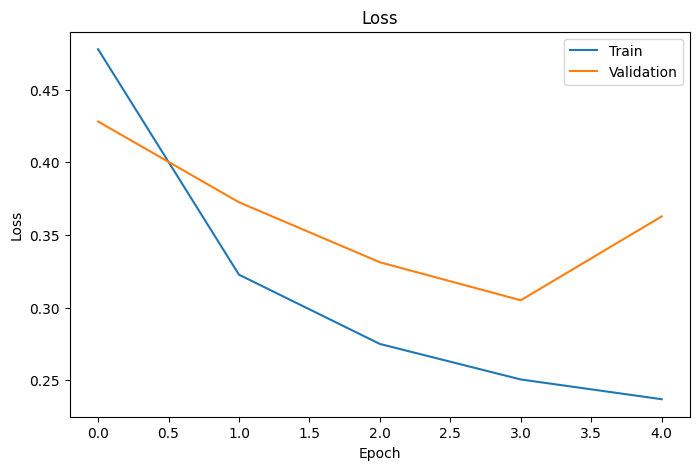

In [15]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

In [16]:
test_generator.reset()

pred_prob = model.predict(test_generator)

pred_class = (pred_prob > 0.5).astype(int)

true_class = test_generator.classes

70/70 ━━━━━━━━━━━━━━━━━━━━ 593s 8s/step


In [17]:
print(
    classification_report(
        true_class,
        pred_class,
        target_names=list(test_generator.class_indices.keys())
    )
)

              precision    recall  f1-score   support

    infected       0.97      0.89      0.93      1109
not_infected       0.90      0.97      0.93      1124

    accuracy                           0.93      2233
   macro avg       0.93      0.93      0.93      2233
weighted avg       0.93      0.93      0.93      2233



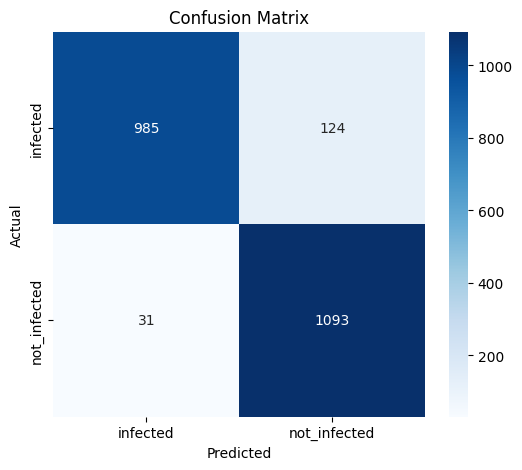

In [18]:
cm = confusion_matrix(
    true_class,
    pred_class
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(test_generator.class_indices.keys()),
    yticklabels=list(test_generator.class_indices.keys())
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

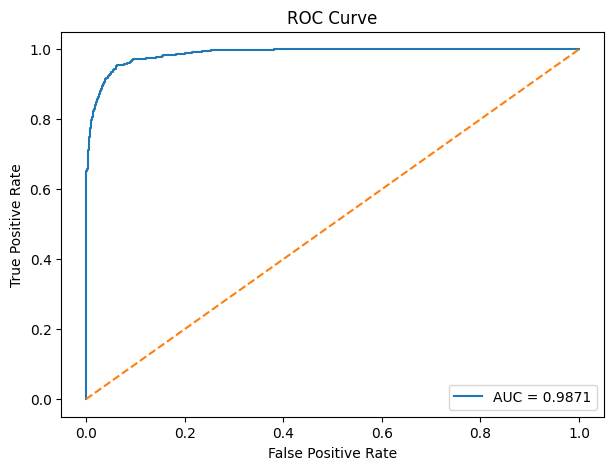

AUC: 0.9870823960542825


In [19]:
fpr, tpr, threshold = roc_curve(
    true_class,
    pred_prob
)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")
plt.legend()

plt.show()

print("AUC:", roc_auc)